#**Case Study 2: Brain Cancer Classification**

#**All General Imports**

In [1]:
import os
import sys
import timeit
import platform
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

#**All Keras Imports**

In [2]:
from tensorflow.keras.models import save_model, Model, Sequential, load_model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.layers import Input, Conv2D, Flatten, MaxPooling2D, Dropout, Dense, GlobalAveragePooling2D
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import array_to_img, img_to_array

#**All Functions Definitions**

In [3]:
def data_download(file_to_download, gdrive_code, OS, uncompress=True):

  if not os.path.exists(file_to_download):
    url = f"https://drive.google.com/uc?id={gdrive_code}"
    os.system(f'gdown "{url}" -O "{file_to_download}"')
    if OS == "Linux" and uncompress:
        os.system(f'unzip -o -n "{file_to_download}" -d "./"')
    return True
  else:
    return None

#**All Data Downloads**

In [4]:
start_time = timeit.default_timer()
# Operating System
OS = platform.system()                           # returns 'Windows', 'Linux', etc

os.system('pip install --upgrade --no-cache-dir gdown')

out = data_download("./brain_tumor_dataset_1.zip", "1IlfIKVCF2nnYndfZWsE7NHPE0si2bof1", OS)
out = data_download("./brain_tumor_dataset_2.zip", "1dYZ4GMfSeCEdnw-JqlgNUsMajHzLCqWp", OS)
print("Elapsed Time: ", timeit.default_timer() - start_time)

Elapsed Time:  20.57809702899999


#**Brain Tumor Classification**

#**All Globals**

In [5]:
negative_dataset_path_1 = "./brain_tumor_dataset_1/no/"
positive_dataset_path_1 = "./brain_tumor_dataset_1/yes/"
negative_dataset_path_2 = "./brain_tumor_dataset_2/no/"
positive_dataset_path_2 = "./brain_tumor_dataset_2/yes/"

dataset_path = [positive_dataset_path_1, negative_dataset_path_1, positive_dataset_path_2, negative_dataset_path_2]
data_type = "float"

#**Hyperparameters**

In [6]:
neural_model = 'brain_net'
transfer_learning = True
epochs = 20
batch_size = 32
width = 256
height = 256
channels = 1
summary = True
val_set_rate = 0.1
test_set_rate = 0.1

#**Initializations**

In [7]:
np.random.seed(42)
dataset = []
labels = []

#**Preprocessing**

In [8]:
for dp in dataset_path:
  images = glob.glob(dp + "*.jpg")
  images.sort()
  if "/yes" in dp:
    label = 1               # tumor patient
  elif "/no" in dp:
    label = 0               # healthy patient
  for x in images:
    image = cv2.imread(x, cv2.IMREAD_GRAYSCALE)
    image = image / 255
    image = cv2.resize(image, (width, height))
    dataset.append(image)
    labels.append(label)

dataset = np.asarray(dataset).astype(data_type)
labels = np.asarray(labels).astype("int")
print("Dataset Shape: ", dataset.shape)
print("Labels Shape: ", labels.shape)

Dataset Shape:  (3171, 256, 256)
Labels Shape:  (3171,)


In [9]:
print(labels)

[1 1 1 ... 0 0 0]


#**Data Shuffle**

In [10]:
indices = np.arange(dataset.shape[0])
np.random.shuffle(indices)
dataset = dataset[indices]
labels = labels[indices]

In [11]:
print(labels)

[1 0 1 ... 1 1 1]


#**Dataset Sample Visualization**

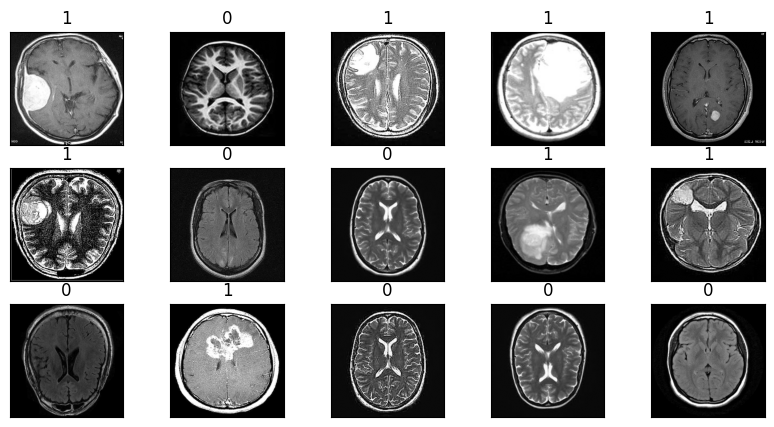

In [12]:
fig = plt.figure(figsize=(10,5))
for i in range(15):
    ax = fig.add_subplot(3, 5, 1 + i, xticks=[], yticks=[])
    ax.set_title(labels[i])
    plt.imshow(dataset[i], cmap = "gray")
plt.show()

#**Train-Val-Test Split**

In [13]:
train_x, val_x, train_y, val_y = train_test_split(dataset, labels, test_size=val_set_rate)
train_x, test_x, train_y, test_y = train_test_split(train_x, train_y, test_size=test_set_rate)

print("Train X Shape: ", train_x.shape)
print("Train Y Shape: ", train_y.shape)
print("Val X Shape: ", val_x.shape)
print("Val Y Shape: ", val_y.shape)
print("Test X Shape: ", test_x.shape)
print("Test Y Shape: ", test_y.shape)

Train X Shape:  (2567, 256, 256)
Train Y Shape:  (2567,)
Val X Shape:  (318, 256, 256)
Val Y Shape:  (318,)
Test X Shape:  (286, 256, 256)
Test Y Shape:  (286,)


#**Model Definitions**

In [14]:
class AvancedBrainModel:

  @staticmethod
  def build(neural_model, transfer_learning, model_input_width, model_input_height, input_channels, summary):
      if transfer_learning is True:
        pretrained_weights = "imagenet"
      else:
        pretrained_weights = None

      if neural_model == 'xception':
          deep_network = Xception(weights=pretrained_weights, include_top=False, input_tensor=Input(shape=(model_input_width, model_input_height, input_channels)))
      elif neural_model == 'resnet':
          deep_network = ResNet50(weights=pretrained_weights, include_top=False, input_tensor=Input(shape=(model_input_width, model_input_height, input_channels)))
      elif neural_model.lower() == 'mobilenet':
          deep_network = MobileNet(weights=pretrained_weights, include_top=False, input_tensor=Input(shape=(model_input_width, model_input_height, input_channels)))
      elif neural_model.lower() == 'inceptionresnet':
          deep_network = InceptionResNetV2(weights=pretrained_weights, include_top=False, input_tensor=Input(shape=(model_input_width, model_input_height, input_channels)))
      elif neural_model.lower() == 'brain_net':
          deep_network = Sequential()
          deep_network.add(Conv2D(32, 4, activation = 'relu', padding = 'same', input_shape=(model_input_width, model_input_height, input_channels)))
          deep_network.add(MaxPooling2D(pool_size=(2, 2)))
          deep_network.add(Dropout(0.5))
          deep_network.add(Conv2D(32, 4, activation = 'relu', padding = 'same'))
          deep_network.add(MaxPooling2D(pool_size=(2, 2)))
          deep_network.add(Dropout(0.3))
          deep_network.add(Conv2D(64, 4, activation = 'relu', padding = 'same'))
          deep_network.add(MaxPooling2D(pool_size=(2, 2)))
          deep_network.add(Dropout(0.3))
          deep_network.add(Flatten())
          deep_network.add(Dense(128, activation='relu'))
          deep_network.add(Dropout(0.15))
          deep_network.add(Dense(1, activation='sigmoid'))
      else:
          print("Neural Model not supported: ", neural_model)
          return None

      if neural_model.lower() != 'brain_net':
        x = deep_network.output
        x = GlobalAveragePooling2D()(x)
        x = Dense(256,activation='relu')(x)
        x = Dropout(0.5)(x)
        predictions = Dense(1, activation='sigmoid')(x)

        deep_network = Model(inputs=deep_network.input, outputs=predictions)

      if summary==True:
          deep_network.summary()

      # return the constructed network architecture
      return deep_network

#**Brain Tumor Classifier Compiling**

In [15]:
brain_tumor_model = AvancedBrainModel.build(neural_model, transfer_learning, width, height, channels, summary)
brain_tumor_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,438,657 (32.19 MB)

 Trainable params: 8,438,657 (32.19 MB)

 Non-trainable params: 0 (0.00 B)

#**Brain Model Training**

In [16]:
best_model_path = f"./best_{neural_model}_brain_model.keras"

checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
history = brain_tumor_model.fit(train_x, train_y, validation_data = (val_x, val_y), epochs = epochs, batch_size = batch_size, callbacks=[checkpoint], verbose=1)

brain_tumor_model = load_model(best_model_path)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6653 - loss: 0.7528
Epoch 1: val_accuracy improved from None to 0.77044, saving model to ./best_brain_net_brain_model.keras

Epoch 1: finished saving model to ./best_brain_net_brain_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 192ms/step - accuracy: 0.7145 - loss: 0.6007 - val_accuracy: 0.7704 - val_loss: 0.5239
Epoch 2/20
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8094 - loss: 0.4255
Epoch 2: val_accuracy improved from 0.77044 to 0.91195, saving model to ./best_brain_net_brain_model.keras

Epoch 2: finished saving model to ./best_brain_net_brain_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8302 - loss: 0.3770 - val_accuracy: 0.9119 - val_loss: 0.3010
Epoch 3/20
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9140 - loss: 0.2194
Epoch 3: val_accuracy improved from 0.91195 to 0.94654, saving model to ./best_brain_net_brain_model.keras

Epoch 3: finished saving model to ./best_brain_net_

#**Brain Cancer Model Evaluation**

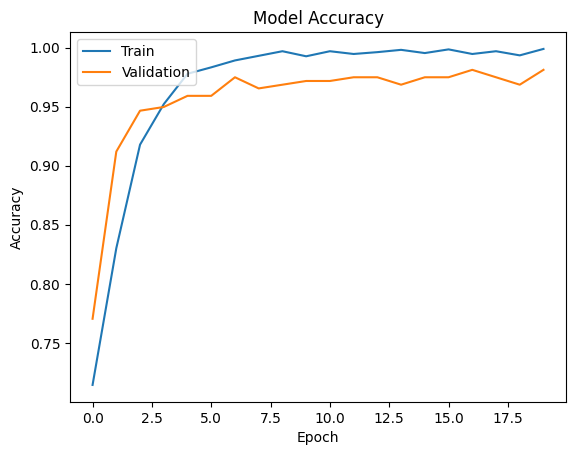

In [17]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

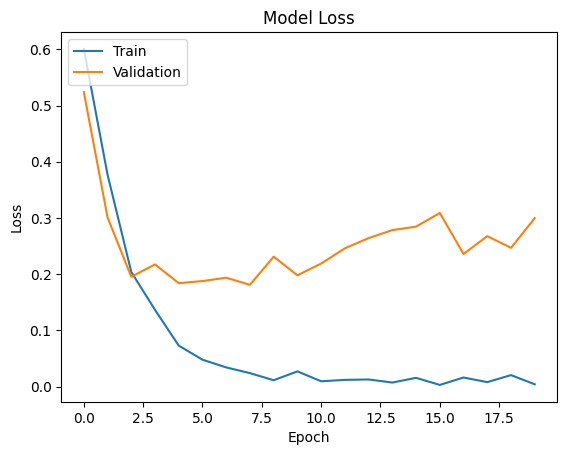

In [18]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [19]:
score = brain_tumor_model.evaluate(test_x, test_y, verbose=0)
print('\n', 'Test accuracy:', score[1])


 Test accuracy: 0.9755244851112366


# **Post-Processing Analysis**

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


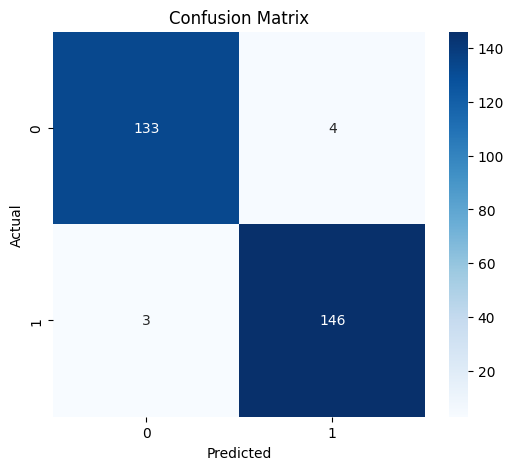

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       137
           1       0.97      0.98      0.98       149

    accuracy                           0.98       286
   macro avg       0.98      0.98      0.98       286
weighted avg       0.98      0.98      0.98       286



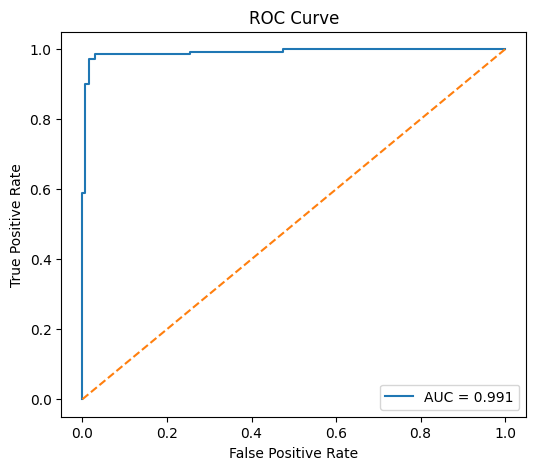

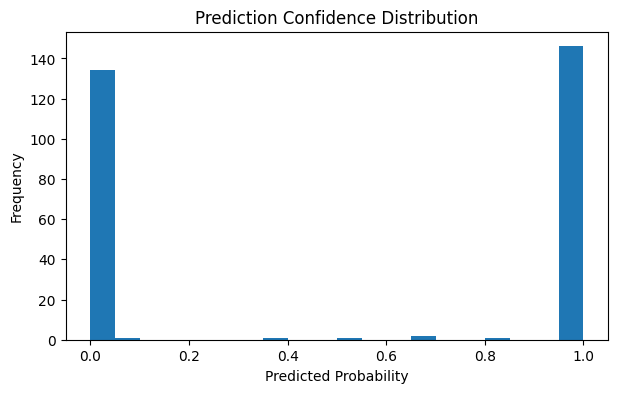

In [20]:
try:
    y_pred_prob = brain_tumor_model.predict(test_x)

    if y_pred_prob.shape[-1] > 1:
        y_pred_classes = np.argmax(y_pred_prob, axis=1)
        y_prob = y_pred_prob[:,1]
    else:
        y_prob = y_pred_prob.ravel()
        y_pred_classes = (y_prob > 0.5).astype(int)

    cm = confusion_matrix(test_y, y_pred_classes)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    print(classification_report(test_y, y_pred_classes))

except Exception as e:
    print("Confusion matrix not available:", e)

try:
    fpr, tpr, thresholds = roc_curve(test_y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label='AUC = %0.3f' % roc_auc)
    plt.plot([0,1], [0,1], linestyle='--')

    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')

    plt.show()

except Exception as e:
    print("ROC curve not available:", e)

try:
    plt.figure(figsize=(7,4))
    plt.hist(y_prob, bins=20)

    plt.title("Prediction Confidence Distribution")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Frequency")

    plt.show()

except Exception as e:
    print("Confidence distribution not available:", e)


/tmp/ipykernel_2259/3802368968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_2259/3802368968.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


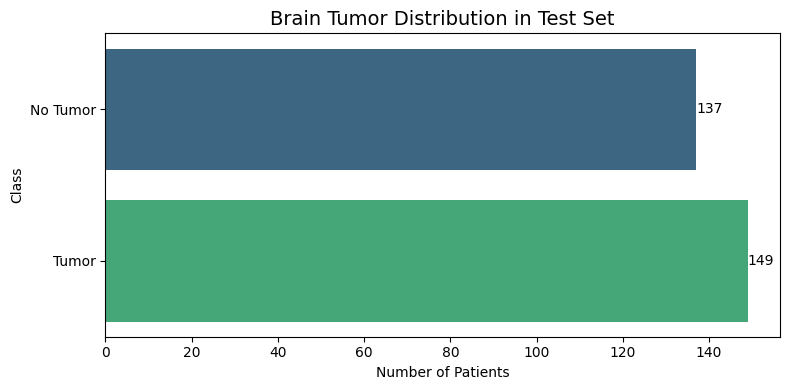

In [21]:
plt.figure(figsize=(8,4))

ax = sns.countplot(
    y=test_y.flatten(),
    palette='viridis'
)

plt.title("Brain Tumor Distribution in Test Set", fontsize=14)
plt.xlabel("Number of Patients")
plt.ylabel("Class")

ax.set_yticklabels([
    'No Tumor',
    'Tumor'
])

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


/tmp/ipykernel_2259/2805567784.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_2259/2805567784.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


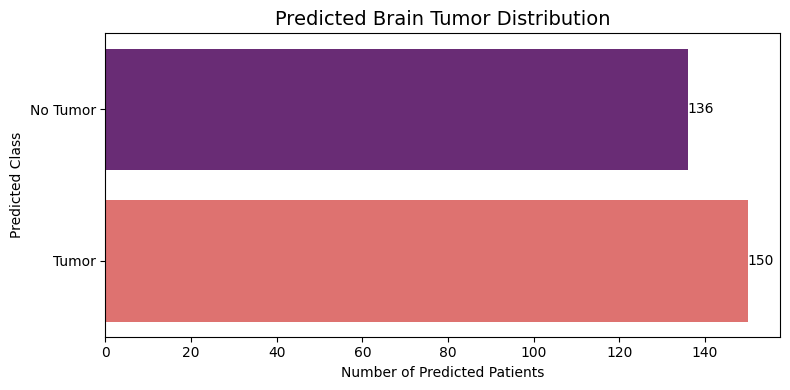

In [22]:
# Predict probabilities
y_pred_prob = brain_tumor_model.predict(test_x)

# Convert probabilities to binary classes
if y_pred_prob.shape[-1] > 1:
    y_pred_classes = np.argmax(y_pred_prob, axis=1)
else:
    y_pred_classes = (y_pred_prob.ravel() > 0.5).astype(int)

# Plot predicted class distribution
plt.figure(figsize=(8,4))

ax = sns.countplot(
    y=y_pred_classes.flatten(),
    palette='magma'
)

plt.title("Predicted Brain Tumor Distribution", fontsize=14)
plt.xlabel("Number of Predicted Patients")
plt.ylabel("Predicted Class")

ax.set_yticklabels([
    'No Tumor',
    'Tumor'
])

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.show()

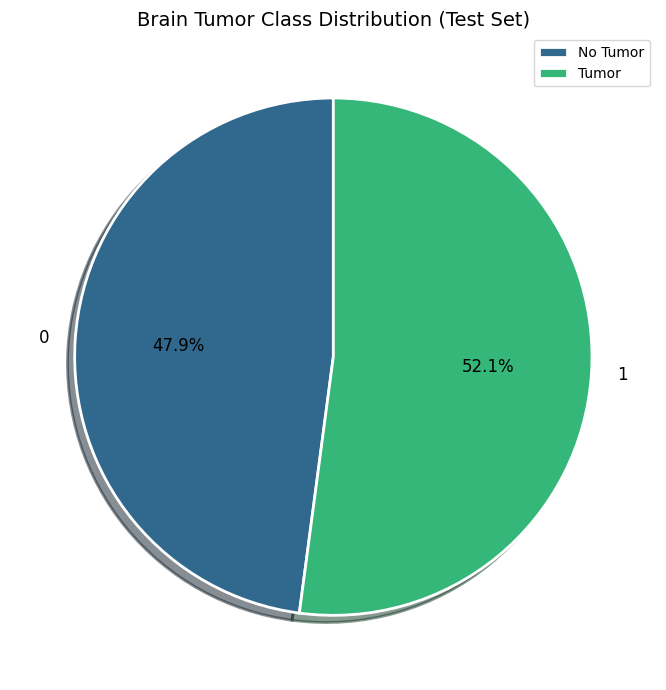

In [25]:
plt.figure(figsize=(7,7))

test_series = pd.Series(test_y.flatten()).value_counts().sort_index()

test_series.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=sns.color_palette('viridis', 2),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)

plt.title("Brain Tumor Class Distribution (Test Set)", fontsize=14)
plt.ylabel('')

plt.legend(
    ['No Tumor', 'Tumor'],
    loc='upper right'
)

plt.tight_layout()

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


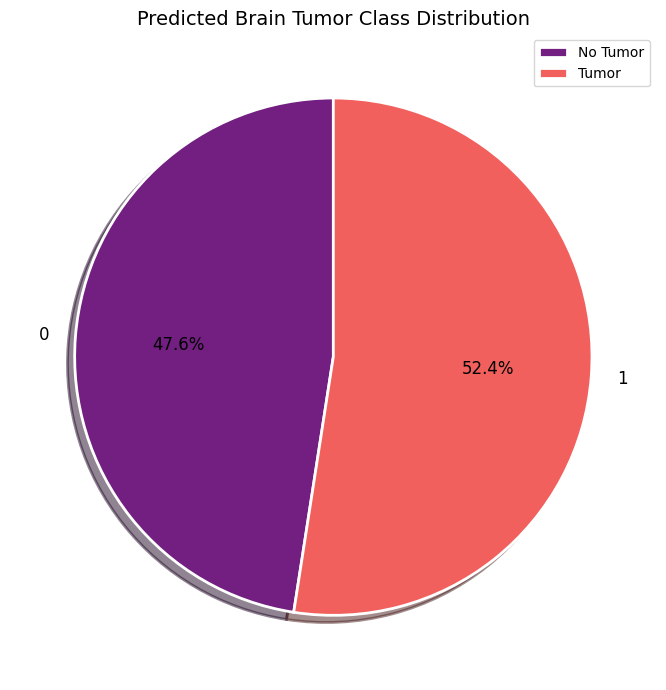

In [24]:
# Predict probabilities
y_pred_prob = brain_tumor_model.predict(test_x)

# Convert probabilities to binary classes
if y_pred_prob.shape[-1] > 1:
    y_pred_classes = np.argmax(y_pred_prob, axis=1)
else:
    y_pred_classes = (y_pred_prob.ravel() > 0.5).astype(int)

# Create ordered series
pred_series = pd.Series(y_pred_classes.flatten()).value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(7,7))

pred_series.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=sns.color_palette('magma', 2),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)

plt.title("Predicted Brain Tumor Class Distribution", fontsize=14)
plt.ylabel('')

plt.legend(
    ['No Tumor', 'Tumor'],
    loc='upper right'
)

plt.tight_layout()

plt.show()